# LOG_DR 視覺化（demo.png）
在 VS Code 的 ipynb 中使用 demo.png 演示 log 動態範圍壓縮前後的效果。

## 1. 安裝與匯入套件
請先在終端（非筆記本）安裝依賴：
```cmd
pip install matplotlib numpy opencv-python
```
以下單元負責匯入套件與公共設定。

In [1]:
from pathlib import Path
import numpy as np
import cv2
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.grid"] = False

# 在 notebook 中 __file__ 不可用，改用工作目錄中的 demo.png
IMAGE_PATH = Path.cwd() / "demo.png"
if not IMAGE_PATH.exists():
    raise FileNotFoundError(f"demo.png not found at {IMAGE_PATH}")

# 方便重用的讀檔函式
def load_image_rgb(path: Path) -> np.ndarray:
    bgr = cv2.imread(str(path), cv2.IMREAD_COLOR)
    if bgr is None:
        raise FileNotFoundError(f"Failed to read image at {path}")
    rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
    return rgb.astype(np.float32) / 255.0


## 2. 讀取 demo.png 並顯示原圖
將影像轉為 RGB 後以 matplotlib 顯示。

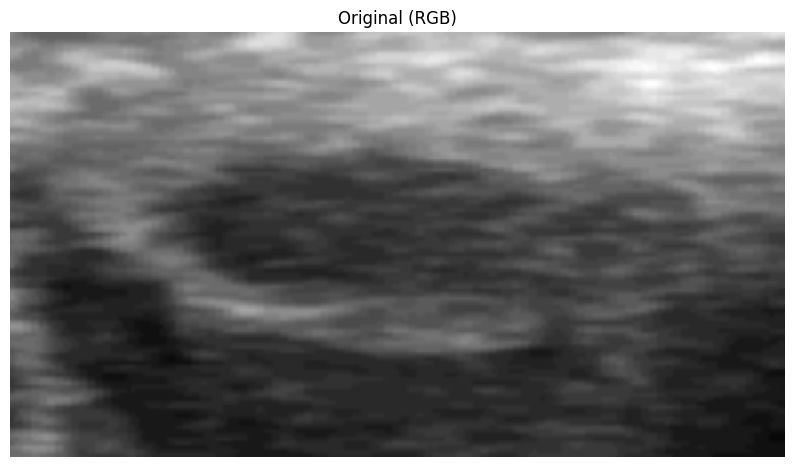

In [2]:
# 讀取並顯示原圖
orig = load_image_rgb(IMAGE_PATH)
plt.imshow(orig)
plt.title("Original (RGB)")
plt.axis("off")
plt.show()


## 3. 套用 log 動態範圍壓縮並視覺化
使用 $f(x)=c \cdot \log(1+x)$，並先以百分位做亮度裁切，再套用 gamma。

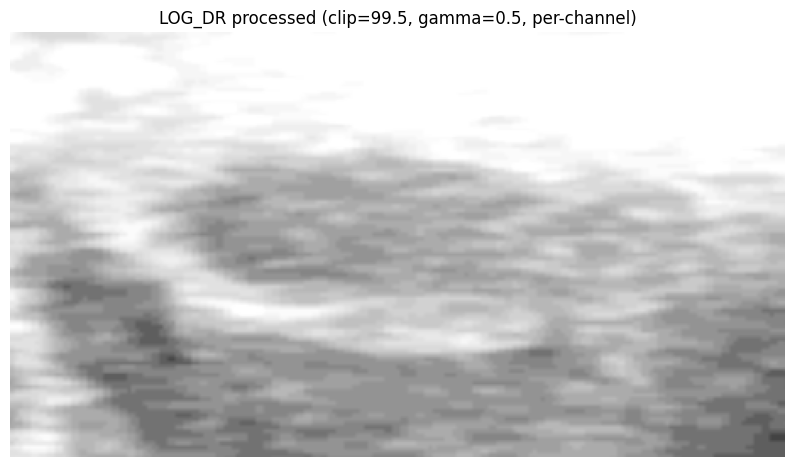

In [3]:
# 定義 LOG_DR 處理並視覺化

def log_dr(
    img: np.ndarray,
    clip_percentile: float = 99.5,
    gamma: float = 0.5,
    eps: float = 1e-6,
    per_channel: bool = True,
) -> np.ndarray:
    """Apply LOG_DR: percentile clip -> normalize -> log1p -> gamma -> re-scale."""
    x = np.clip(img, 0.0, 1.0)
    if per_channel:
        clip_max = np.percentile(x, clip_percentile, axis=(0, 1), keepdims=True)
    else:
        clip_max = np.percentile(x, clip_percentile)
    clip_max = np.maximum(clip_max, eps)
    norm = np.clip(x / clip_max, 0.0, 1.0)

    log_x = np.log1p(norm)
    log_x = np.power(log_x, gamma)

    # normalize to [0,1]; log1p(1)=ln(2) for scaling constant c
    log_x = np.clip(log_x / np.log1p(1.0), 0.0, 1.0)
    return log_x

log_img = log_dr(orig, clip_percentile=99.5, gamma=0.5, eps=1e-6, per_channel=True)
plt.imshow(log_img)
plt.title("LOG_DR processed (clip=99.5, gamma=0.5, per-channel)")
plt.axis("off")
plt.show()


## 4. 原圖 vs. LOG 處理後對照
並排觀察亮度壓縮與細節變化。

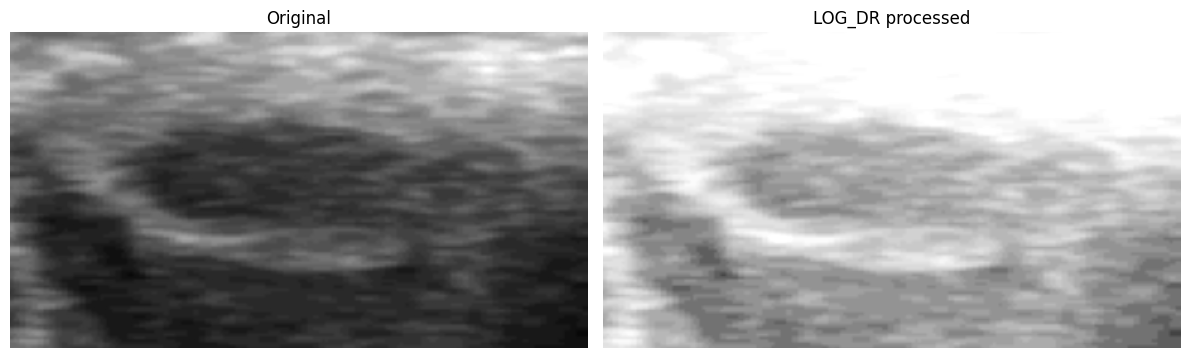

In [4]:
# 並排比較
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(orig)
axes[0].set_title("Original")
axes[0].axis("off")
axes[1].imshow(log_img)
axes[1].set_title("LOG_DR processed")
axes[1].axis("off")
plt.tight_layout()
plt.show()


## 5. 額外參數實驗：不同 log 基底與縮放因子
調整 clip 百分位、log 基底與 gamma，觀察壓縮效果。

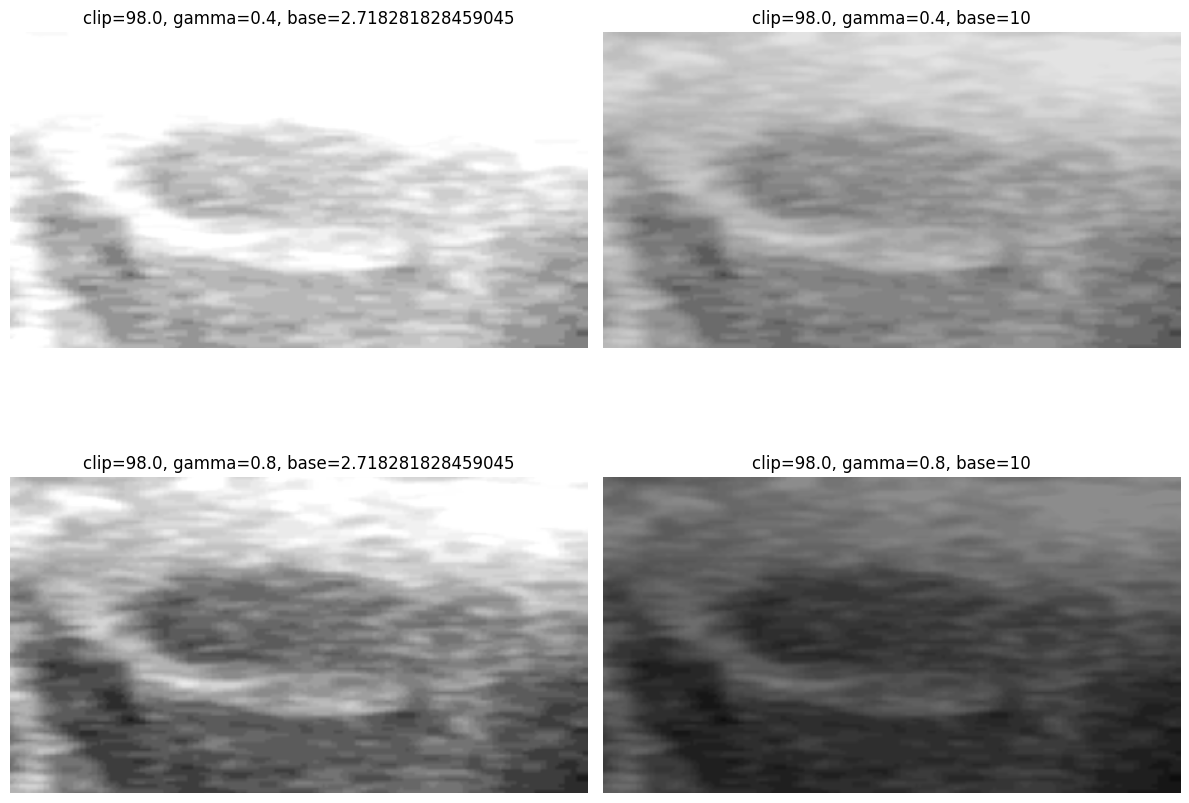

In [5]:
# 多組參數對照

from itertools import product

def log_dr_variant(
    img: np.ndarray,
    clip_percentile: float,
    gamma: float,
    base: float,
    eps: float = 1e-6,
) -> np.ndarray:
    x = np.clip(img, 0.0, 1.0)
    clip_max = np.percentile(x, clip_percentile, axis=(0, 1), keepdims=True)
    clip_max = np.maximum(clip_max, eps)
    norm = np.clip(x / clip_max, 0.0, 1.0)
    # log base change via ln(x)/ln(base)
    log_x = np.log1p(norm) / np.log(base)
    log_x = np.power(log_x, gamma)
    log_x = np.clip(log_x / np.log1p(1.0), 0.0, 1.0)
    return log_x

variants = list(product([98.0, 99.5], [0.4, 0.8], [np.e, 10]))  # (clip, gamma, base)
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
for ax, (clip, gamma, base) in zip(axes.flat, variants):
    v = log_dr_variant(orig, clip_percentile=clip, gamma=gamma, base=base)
    ax.imshow(v)
    ax.set_title(f"clip={clip}, gamma={gamma}, base={base}")
    ax.axis("off")
plt.tight_layout()
plt.show()
